# Chile: dimensionality and initialization comparisons

Run this notebook independently from a fresh kernel to inspect the eight additional Chilean fits. **`REFIT = False` loads the supplied weights, reevaluates held-out choices and regenerates coordinates, metrics and plots.** Set it to `True` to repeat the visible training loop. Eight new fits can take hours on a CPU. Use a different `OUTPUT` directory to keep experiments separate from the paper results.

**Inputs:** the included `Chile_pairs.parquet`, `Chile_split_assignments.parquet` and `participant_age_decisions.csv` in `data/processed/`, generated by notebooks 01 and 02. Saved-fit mode also reads each fit's weights, specification, history and metrics in `outputs/models/`. The main `(dimension=2, seed=101)` fit from notebook 02 is a supplied input to the final comparison and is not trained here.

**Outputs:** regenerated fit coordinates and metrics in `outputs/models/`, comparisons in `outputs/diagnostics/`, and training/comparison plots in `outputs/figures/`. All inputs are included, so earlier notebooks need not run first.

Every fit uses the same age-filtered participants and held-out split. Unknown age is retained, and every participant has at least one training choice. Only dimension or initialization seed varies. The intermediate [8, 8] head used by the paper has 105 parameters, while [3] has 13. Both remain selectable below alongside the original head, which has `4 × dimension + 12` parameters. Embedding parameters are additional.


In [1]:
from pathlib import Path
import json
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import tensorflow as tf

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "data/raw").is_dir(), "Open from the project root or notebooks directory."
sys.path.insert(0, str(ROOT / "src"))
from choice_models import build_choice_model

assert tf.__version__.startswith(
    "2.15."
), "Use TensorFlow 2.15, as specified in requirements.txt."
PROCESSED = ROOT / "data/processed"
OUTPUT = ROOT / "outputs"
for folder in [
    PROCESSED,
    OUTPUT / "models",
    OUTPUT / "diagnostics",
    OUTPUT / "figures",
    OUTPUT / "tables",
]:
    folder.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

# False reloads the included manuscript fit. True trains a new fit and replaces
# its weights, coordinates and history in OUTPUT. Change OUTPUT to keep experiments separate.
REFIT = False
VARIANT = "intermediate"  # "original" selects the fully flexible head.
HIDDEN_SIZES = [8, 8]  # [3] selects the compact 13-parameter intermediate head.
MINIMUM_SCALE = 1e-6  # Positive floor for the intermediate distance multiplier.
MODEL_SETTINGS = dict(variant=VARIANT, hidden_sizes=HIDDEN_SIZES, minimum_scale=MINIMUM_SCALE)
EPOCHS = 20  # Always use the final epoch, not the best held-out epoch.
BATCH_SIZE = 64
LEARNING_RATE = 0.01  # Adamax learning rate.
STEPS_PER_EXECUTION = 64  # Groups graph execution calls, not optimizer updates.
DEVICE = "/CPU:0"

FIT_SPECIFICATIONS = [
    (1, 101),
    (3, 101),
    (4, 101),
    (10, 101),
    (2, 201),
    (2, 301),
    (2, 401),
    (2, 501),
]
specification_table = pd.DataFrame(FIT_SPECIFICATIONS, columns=["dimension", "seed"])
display(specification_table)
specification_table.to_csv(
    OUTPUT / "diagnostics/Chile_additional_fit_specifications.csv", index=False
)
specification_table.to_latex(
    OUTPUT / "diagnostics/Chile_additional_fit_specifications.tex", index=False
)


,dimension,seed
0,1,101
1,3,101
2,4,101
3,10,101
4,2,201
5,2,301
6,2,401
7,2,501


## Read the existing sample and split

Participant and proposal indices follow notebook 02's sorted identifier order.
Within-participant record order is `id, datetime`. Joining split labels by both
record and participant identifier verifies that the saved assignments cover the
current data exactly. The assertions reject excluded IDs, duplicate records,
missing assignments, and participants without a training choice.

In [2]:
pairs = pd.read_parquet(PROCESSED / "Chile_pairs.parquet")
assignments = pd.read_parquet(PROCESSED / "Chile_split_assignments.parquet")
age_decisions = pd.read_csv(
    PROCESSED / "participant_age_decisions.csv", dtype={"uuid": "string"}
)
age_decisions = age_decisions.loc[age_decisions["country"].eq("Chile")].copy()
include_decisions = (
    age_decisions["include"]
    .astype(str)
    .str.lower()
    .map({"true": True, "false": False, "1": True, "0": False})
)
assert include_decisions.notna().all()
excluded_ids = set(age_decisions.loc[~include_decisions.astype(bool), "uuid"])
assert not set(pairs["uuid"]) & excluded_ids
assert pairs["id"].is_unique and assignments["id"].is_unique
assert len(pairs) == len(assignments)

ordered = pairs.sort_values(["uuid", "id", "datetime"], kind="mergesort").reset_index(drop=True)
ordered = ordered.merge(
    assignments, on=["id", "uuid"], how="left", validate="one_to_one", sort=False
)
assert ordered["split"].isin(["train", "test"]).all()
users = np.array(sorted(ordered["uuid"].unique()))
options = np.array(sorted(set(ordered["option_a"]) | set(ordered["option_b"])))
user_index = {uuid: index for index, uuid in enumerate(users)}
option_index = {option: index for index, option in enumerate(options)}
# Integer indices preserve the exact row meaning of the supplied embeddings.
X_all = np.column_stack(
    [
        ordered["option_a"].map(option_index),
        ordered["uuid"].map(user_index),
        ordered["option_b"].map(option_index),
    ]
).astype(np.int32)
y_all = ordered["selected"].eq(ordered["option_a"]).to_numpy(dtype=np.int32)
is_training = ordered["split"].eq("train").to_numpy()
X_train, y_train = X_all[is_training], y_all[is_training]
X_test, y_test = X_all[~is_training], y_all[~is_training]
assert set(X_train[:, 1]) == set(range(len(users)))
assert set(X_test[:, 1]).issubset(set(X_train[:, 1]))
assert len(options) == 90

participant_support = ordered.groupby("uuid").size().rename("total_choices").reset_index()
singleton_count = int(participant_support["total_choices"].eq(1).sum())
sample_summary = pd.DataFrame(
    [
        {
            "participants": len(users),
            "proposals": len(options),
            "records": len(ordered),
            "training_records": len(y_train),
            "test_records": len(y_test),
            "training_participants": len(np.unique(X_train[:, 1])),
            "test_participants": len(np.unique(X_test[:, 1])),
            "singleton_participants_assigned_to_train": singleton_count,
        }
    ]
)
display(sample_summary)
sample_summary.to_csv(OUTPUT / "diagnostics" / "Chile_additional_fit_sample.csv", index=False)
sample_summary.to_latex(OUTPUT / "diagnostics" / "Chile_additional_fit_sample.tex", index=False)


,participants,proposals,records,training_records,test_records,training_participants,test_participants,singleton_participants_assigned_to_train
0,47574,90,2970347,2650103,320244,47574,47566,8


## Load or fit each specification

Each iteration constructs an independent model and optimizer. Python, NumPy and TensorFlow use the stated seed. The supplied model specification and sorted IDs must match before its weights can load. This check includes head widths, dimension and both seed roles.

With refitting enabled, all fits use 20 fixed epochs, Adamax at 0.01 and batches of 64. Every row is used, including the final incomplete batch. With refitting disabled, history and elapsed training time come from that fit's original training. Final coordinates and held-out metrics are computed from the loaded model. No demographic variable or ideological label enters the choice model.


Loading Chile_dim1_seed101: 47,574 participants, 2,650,103 training choices.


,tensor,shape,parameters
0,proposal_coordinates:0,"(90, 1)",90
1,participant_coordinates:0,"(47574, 1)",47574
2,symmetric_positive_choice/kernel:0,"(2, 8)",16
3,symmetric_positive_choice/bias:0,"(8,)",8
4,symmetric_positive_choice/kernel:0,"(8, 8)",64
5,symmetric_positive_choice/bias:0,"(8,)",8
6,symmetric_positive_choice/kernel:0,"(8, 1)",8
7,symmetric_positive_choice/bias:0,"(1,)",1


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.612565,0.662651,0.616191,0.659547
1,2,0.605879,0.668512,0.616898,0.659756
2,3,0.603940,0.670298,0.617196,0.658067
3,4,0.603134,0.671047,0.617535,0.658635
4,5,0.602385,0.671555,0.617799,0.657998
5,6,0.601506,0.672273,0.617431,0.657930
6,7,0.600809,0.672442,0.618564,0.657567
7,8,0.600132,0.672714,0.618730,0.657314
8,9,0.599575,0.673228,0.618169,0.657901
9,10,0.598932,0.673486,0.617714,0.657302


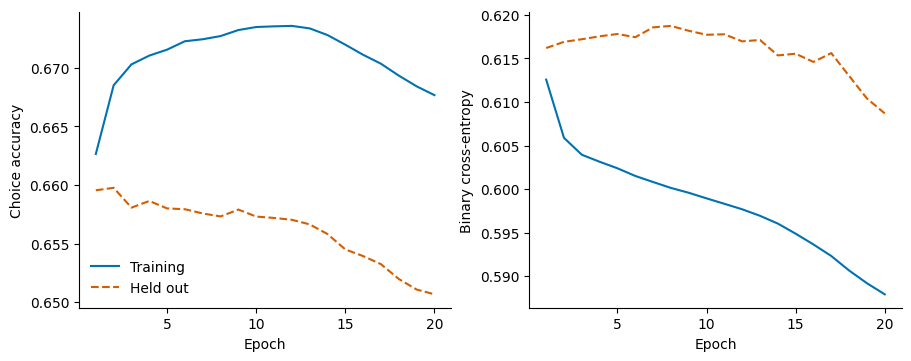

,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,1,101,47574,90,2970347,2650103,320244,0.608686,0.650666,0.650666,8,654.401812


,uuid,z1
0,000057c7-295c-4a61-8f62-76aff62bf079,0.350295
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.594163
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.482529
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.564768
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.614691
...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.438519
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.633399
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.450230
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.531923


,id,z1
0,1,0.236580
1,2,1.000000
2,3,0.548294
3,4,0.814619
4,5,0.282994
...,...,...
85,86,0.804895
86,87,0.571752
87,88,0.174455
88,89,0.301355


Model: "dynamap_intermediate"


_________________________________________________________________


...

_________________________________________________________________


{'dimension': 1,
 'embedding_seed': 101,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 90,
 'n_users': 47574,
 'seed': 101,
 'variant': 'intermediate'}

Loading Chile_dim3_seed101: 47,574 participants, 2,650,103 training choices.


,tensor,shape,parameters
0,proposal_coordinates:0,"(90, 3)",270
1,participant_coordinates:0,"(47574, 3)",142722
2,symmetric_positive_choice/kernel:0,"(2, 8)",16
3,symmetric_positive_choice/bias:0,"(8,)",8
4,symmetric_positive_choice/kernel:0,"(8, 8)",64
5,symmetric_positive_choice/bias:0,"(8,)",8
6,symmetric_positive_choice/kernel:0,"(8, 1)",8
7,symmetric_positive_choice/bias:0,"(1,)",1


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.603871,0.671205,0.592516,0.681221
1,2,0.562221,0.706771,0.575740,0.696032
2,3,0.545093,0.720152,0.571318,0.699832
3,4,0.537995,0.725817,0.568133,0.701243
4,5,0.534236,0.728553,0.567586,0.701515
5,6,0.531655,0.730515,0.566494,0.701702
6,7,0.529627,0.731994,0.568491,0.701912
7,8,0.528088,0.732984,0.567227,0.701524
8,9,0.526839,0.733696,0.568994,0.701674
9,10,0.525795,0.734431,0.566977,0.701478


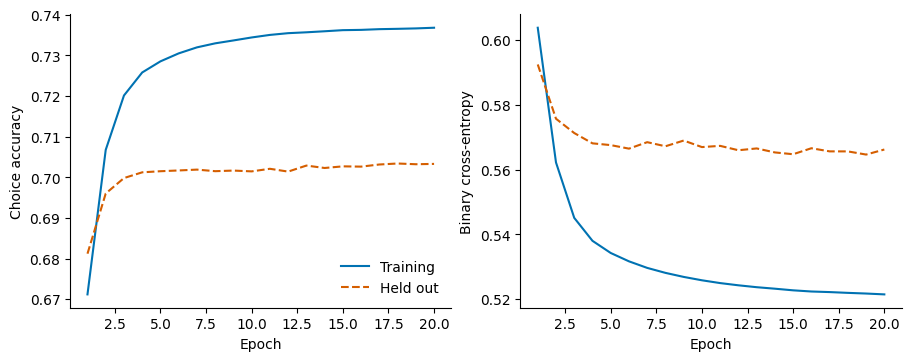

,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,3,101,47574,90,2970347,2650103,320244,0.566223,0.703317,0.703317,8,2149.870067


,uuid,z1,z2,z3
0,000057c7-295c-4a61-8f62-76aff62bf079,0.256022,0.633336,0.595253
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.000935,0.400091,0.102736
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.451322,0.002611,0.350353
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.398863,0.339715,0.455154
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.208687,0.489613,0.245857
...,...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.433529,0.282300,0.309902
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.316493,0.898317,0.369228
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.988992,0.029036,0.200218
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.079004,0.367540,0.285784


,id,z1,z2,z3
0,1,0.624562,0.712343,0.621660
1,2,0.789747,0.750122,0.931575
2,3,0.363240,0.560987,0.560924
3,4,0.392614,0.366583,0.852324
4,5,0.510163,1.000000,0.476034
...,...,...,...,...
85,86,0.538402,0.332725,0.758377
86,87,0.416992,0.638892,0.021989
87,88,0.759881,0.376169,0.719782
88,89,0.604828,0.805262,0.508152


Model: "dynamap_intermediate"


_________________________________________________________________


...

_________________________________________________________________


{'dimension': 3,
 'embedding_seed': 101,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 90,
 'n_users': 47574,
 'seed': 101,
 'variant': 'intermediate'}

Loading Chile_dim4_seed101: 47,574 participants, 2,650,103 training choices.


,tensor,shape,parameters
0,proposal_coordinates:0,"(90, 4)",360
1,participant_coordinates:0,"(47574, 4)",190296
2,symmetric_positive_choice/kernel:0,"(2, 8)",16
3,symmetric_positive_choice/bias:0,"(8,)",8
4,symmetric_positive_choice/kernel:0,"(8, 8)",64
5,symmetric_positive_choice/bias:0,"(8,)",8
6,symmetric_positive_choice/kernel:0,"(8, 1)",8
7,symmetric_positive_choice/bias:0,"(1,)",1


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.599100,0.674995,0.584659,0.687263
1,2,0.551520,0.714942,0.569745,0.700466
2,3,0.532450,0.729845,0.565408,0.704085
3,4,0.523220,0.736784,0.560381,0.706539
4,5,0.517857,0.740613,0.558941,0.707682
5,6,0.514383,0.743087,0.558024,0.707948
6,7,0.511928,0.744825,0.560300,0.708201
7,8,0.510147,0.746067,0.559398,0.708706
8,9,0.508795,0.746970,0.562343,0.708672
9,10,0.507745,0.747744,0.559285,0.708841


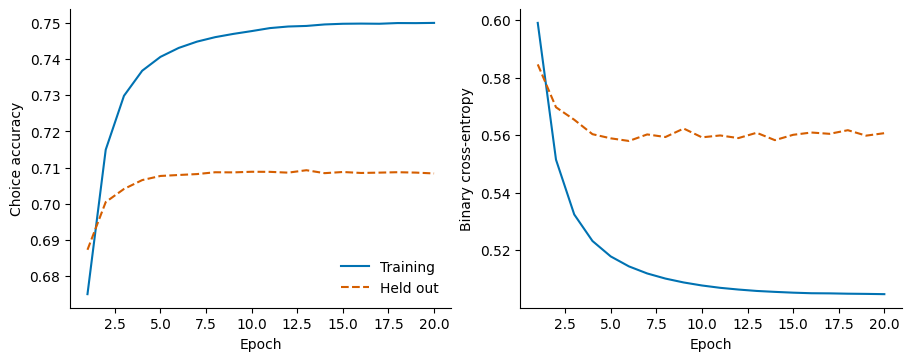

,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,4,101,47574,90,2970347,2650103,320244,0.560734,0.708376,0.708376,8,1159.752744


,uuid,z1,z2,z3,z4
0,000057c7-295c-4a61-8f62-76aff62bf079,0.601316,0.521788,0.742928,0.671306
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.789638,0.000103,0.518738,0.436350
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.836249,0.599653,0.297193,0.004977
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.710659,0.306998,0.395129,0.226717
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.475794,0.275424,0.544894,0.309522
...,...,...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.400382,0.416342,0.369228,0.238246
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.437169,0.196720,0.812620,0.774732
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.255436,0.947635,0.179752,0.011334
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.729064,0.069817,0.695328,0.411247


,id,z1,z2,z3,z4
0,1,0.288932,0.445705,0.205470,0.889330
1,2,0.437372,0.984213,0.524171,0.999094
2,3,0.440656,0.458421,0.822368,0.347903
3,4,0.773758,0.436852,0.111745,0.801334
4,5,0.126172,0.393506,0.729254,0.920178
...,...,...,...,...,...
85,86,0.603132,0.499473,0.006860,0.691217
86,87,0.140373,0.071318,0.322782,0.496458
87,88,0.500080,0.921932,0.261492,0.549825
88,89,0.278591,0.601616,0.601180,0.784392


Model: "dynamap_intermediate"


_________________________________________________________________


...

_________________________________________________________________


{'dimension': 4,
 'embedding_seed': 101,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 90,
 'n_users': 47574,
 'seed': 101,
 'variant': 'intermediate'}

Loading Chile_dim10_seed101: 47,574 participants, 2,650,103 training choices.


,tensor,shape,parameters
0,proposal_coordinates:0,"(90, 10)",900
1,participant_coordinates:0,"(47574, 10)",475740
2,symmetric_positive_choice/kernel:0,"(2, 8)",16
3,symmetric_positive_choice/bias:0,"(8,)",8
4,symmetric_positive_choice/kernel:0,"(8, 8)",64
5,symmetric_positive_choice/bias:0,"(8,)",8
6,symmetric_positive_choice/kernel:0,"(8, 1)",8
7,symmetric_positive_choice/bias:0,"(1,)",1


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.583157,0.688159,0.563147,0.703370
1,2,0.515128,0.741678,0.550633,0.715108
2,3,0.487468,0.762815,0.551016,0.717434
3,4,0.473623,0.772899,0.545798,0.718349
4,5,0.465107,0.778775,0.546222,0.718746
5,6,0.459418,0.782654,0.547695,0.719876
6,7,0.455292,0.785253,0.552782,0.719083
7,8,0.452165,0.787155,0.552609,0.719745
8,9,0.449716,0.788602,0.555535,0.719189
9,10,0.447803,0.789857,0.554717,0.719030


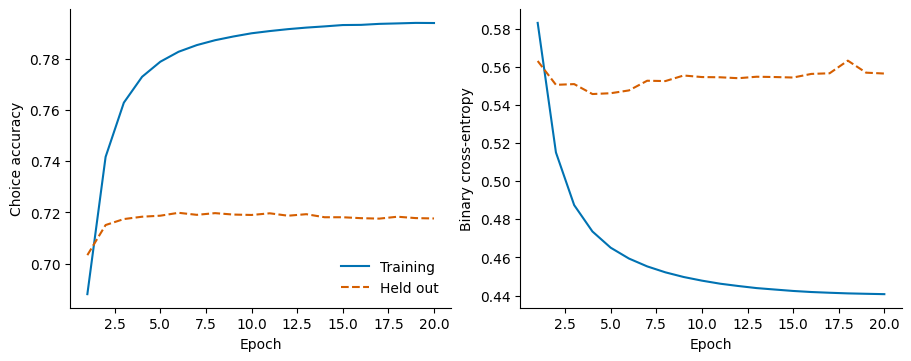

,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,10,101,47574,90,2970347,2650103,320244,0.556558,0.717668,0.717668,8,2683.109397


,uuid,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10
0,000057c7-295c-4a61-8f62-76aff62bf079,0.298993,0.446690,0.439149,0.657472,0.250211,0.261709,0.563353,0.343514,0.609205,0.208434
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.970076,0.573610,0.798087,0.727289,0.178922,0.082573,0.051290,0.443819,0.138514,0.583197
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.219833,0.212114,0.697476,0.382500,0.735537,0.485956,0.157393,0.412875,0.060493,0.812466
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.307511,0.481205,0.652708,0.343325,0.244910,0.356755,0.334009,0.430583,0.173332,0.636777
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.716406,0.435976,0.569024,0.416526,0.102334,0.375446,0.269613,0.517438,0.377807,0.643238
...,...,...,...,...,...,...,...,...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.362028,0.225021,0.411343,0.670650,0.617398,0.516863,0.169274,0.691207,0.228962,0.455500
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.786613,0.800612,0.687100,0.774298,0.206965,0.248135,0.712367,0.801972,0.179701,0.439344
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.173567,0.051193,0.389712,0.090909,0.772000,0.811607,0.673970,0.768531,0.125643,0.690505
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.694501,0.807704,0.638015,0.423838,0.218127,0.376265,0.210199,0.278088,0.434512,0.806040


,id,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10
0,1,0.590314,0.549478,0.411803,0.944636,5.486140e-01,0.802982,0.000106,0.789355,0.776527,0.622645
1,2,0.459764,1.000000,0.129319,0.538300,3.821734e-01,0.887471,0.962940,0.599679,0.400380,0.771638
2,3,0.430908,0.399668,0.810570,0.552490,3.262187e-01,0.256035,0.330973,0.771973,0.108034,0.091987
3,4,0.993321,0.749932,0.637010,0.463284,8.262286e-01,0.466862,0.238932,0.018579,0.530109,0.678087
4,5,0.703645,0.653580,0.581240,0.747527,6.125640e-01,0.154410,0.700766,0.714752,0.871365,0.000032
...,...,...,...,...,...,...,...,...,...,...,...
85,86,0.809186,0.787434,0.181285,0.191981,8.219101e-01,0.246662,0.111166,0.273657,0.359415,0.685898
86,87,0.702880,0.358407,0.202912,0.590743,5.142154e-01,0.043212,0.002479,0.699509,0.780424,0.514682
87,88,0.405959,0.442145,0.746491,0.059292,1.243465e-01,0.851884,0.323106,0.283257,0.802496,0.767660
88,89,0.593984,0.695969,0.348003,0.403209,6.009653e-08,0.372775,0.805420,0.810224,0.381753,0.663301


Model: "dynamap_intermediate"


_________________________________________________________________


...

_________________________________________________________________


{'dimension': 10,
 'embedding_seed': 101,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 90,
 'n_users': 47574,
 'seed': 101,
 'variant': 'intermediate'}

Loading Chile_dim2_seed201: 47,574 participants, 2,650,103 training choices.


,tensor,shape,parameters
0,proposal_coordinates:0,"(90, 2)",180
1,participant_coordinates:0,"(47574, 2)",95148
2,symmetric_positive_choice/kernel:0,"(2, 8)",16
3,symmetric_positive_choice/bias:0,"(8,)",8
4,symmetric_positive_choice/kernel:0,"(8, 8)",64
5,symmetric_positive_choice/bias:0,"(8,)",8
6,symmetric_positive_choice/kernel:0,"(8, 1)",8
7,symmetric_positive_choice/bias:0,"(1,)",1


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.606090,0.669019,0.600178,0.675657
1,2,0.575662,0.696371,0.586611,0.686839
2,3,0.563168,0.706481,0.583409,0.689793
3,4,0.558174,0.710696,0.583274,0.690680
4,5,0.555720,0.712734,0.583201,0.690436
5,6,0.554308,0.713980,0.584863,0.690386
6,7,0.553415,0.714974,0.584877,0.689943
7,8,0.552812,0.715668,0.584938,0.689705
8,9,0.552357,0.716101,0.588035,0.688987
9,10,0.552095,0.716315,0.585257,0.688884


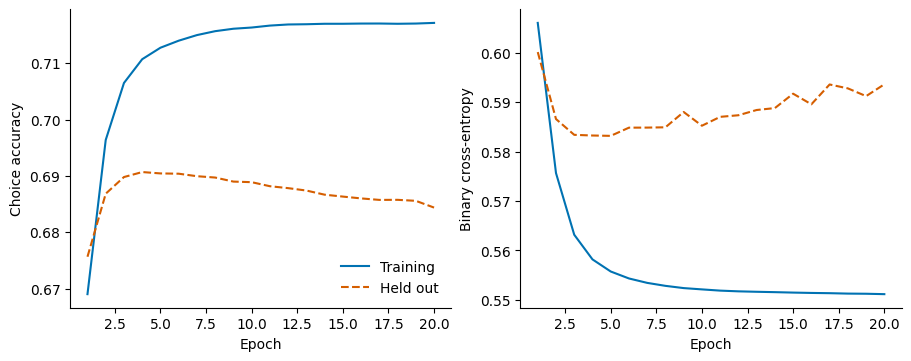

,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,201,47574,90,2970347,2650103,320244,0.593649,0.684375,0.684375,8,818.428899


,uuid,z1,z2
0,000057c7-295c-4a61-8f62-76aff62bf079,0.508094,0.273630
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.608188,0.309493
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.686655,0.923053
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.503394,0.447530
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.573879,0.351249
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.624283,0.545440
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.413050,0.135501
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.609547,0.989968
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.500307,0.532964


,id,z1,z2
0,1,2.027565e-01,0.448028
1,2,1.896641e-09,1.000000
2,3,6.232877e-01,0.385307
3,4,1.871594e-01,0.643082
4,5,3.514348e-01,0.052619
...,...,...,...
85,86,3.236359e-01,0.690586
86,87,5.856144e-01,0.376354
87,88,2.168506e-01,0.833339
88,89,6.680774e-01,0.182382


Model: "dynamap_intermediate"


_________________________________________________________________


...

_________________________________________________________________


{'dimension': 2,
 'embedding_seed': 201,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 90,
 'n_users': 47574,
 'seed': 201,
 'variant': 'intermediate'}

Loading Chile_dim2_seed301: 47,574 participants, 2,650,103 training choices.


,tensor,shape,parameters
0,proposal_coordinates:0,"(90, 2)",180
1,participant_coordinates:0,"(47574, 2)",95148
2,symmetric_positive_choice/kernel:0,"(2, 8)",16
3,symmetric_positive_choice/bias:0,"(8,)",8
4,symmetric_positive_choice/kernel:0,"(8, 8)",64
5,symmetric_positive_choice/bias:0,"(8,)",8
6,symmetric_positive_choice/kernel:0,"(8, 1)",8
7,symmetric_positive_choice/bias:0,"(1,)",1


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.601668,0.672911,0.594155,0.680540
1,2,0.570383,0.700852,0.584226,0.689596
2,3,0.560119,0.709613,0.580884,0.691816
3,4,0.555978,0.713167,0.580821,0.692572
4,5,0.553524,0.714843,0.580777,0.692531
5,6,0.552145,0.716247,0.580669,0.691866
6,7,0.551200,0.716669,0.581700,0.691626
7,8,0.550682,0.717018,0.584172,0.690558
8,9,0.550369,0.717329,0.582891,0.690296
9,10,0.550162,0.717463,0.584931,0.689758


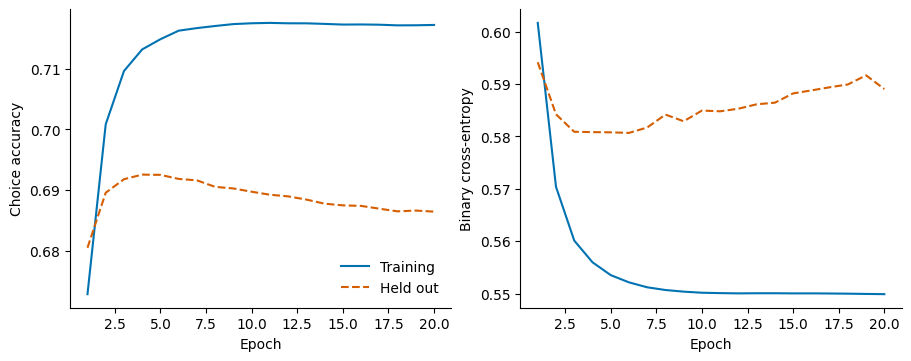

,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,301,47574,90,2970347,2650103,320244,0.589048,0.686483,0.686483,8,714.493242


,uuid,z1,z2
0,000057c7-295c-4a61-8f62-76aff62bf079,0.207972,0.485650
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.137186,0.479679
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.655070,0.089794
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.349269,0.278113
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.244110,0.463618
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.752124,0.318797
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.400149,0.824130
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.912399,0.181425
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.193664,0.474198


,id,z1,z2
0,1,4.762311e-01,0.727914
1,2,1.056180e-08,1.000000
2,3,2.168452e-01,0.446672
3,4,1.961155e-02,0.216427
4,5,1.868094e-01,0.863994
...,...,...,...
85,86,1.151500e-01,0.168026
86,87,2.295039e-01,0.445092
87,88,8.245342e-01,0.401289
88,89,4.268905e-01,0.724659


Model: "dynamap_intermediate"


_________________________________________________________________


...

_________________________________________________________________


{'dimension': 2,
 'embedding_seed': 301,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 90,
 'n_users': 47574,
 'seed': 301,
 'variant': 'intermediate'}

Loading Chile_dim2_seed401: 47,574 participants, 2,650,103 training choices.


,tensor,shape,parameters
0,proposal_coordinates:0,"(90, 2)",180
1,participant_coordinates:0,"(47574, 2)",95148
2,symmetric_positive_choice/kernel:0,"(2, 8)",16
3,symmetric_positive_choice/bias:0,"(8,)",8
4,symmetric_positive_choice/kernel:0,"(8, 8)",64
5,symmetric_positive_choice/bias:0,"(8,)",8
6,symmetric_positive_choice/kernel:0,"(8, 1)",8
7,symmetric_positive_choice/bias:0,"(1,)",1


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.609845,0.665251,0.610018,0.666907
1,2,0.587095,0.685827,0.593827,0.680213
2,3,0.569978,0.701341,0.586257,0.687332
3,4,0.561499,0.708562,0.583491,0.690111
4,5,0.557271,0.711965,0.582737,0.691045
5,6,0.555013,0.713543,0.584511,0.690770
6,7,0.553992,0.714581,0.584782,0.690030
7,8,0.553565,0.714929,0.585524,0.689584
8,9,0.553401,0.715265,0.587376,0.689318
9,10,0.553437,0.715599,0.588650,0.688478


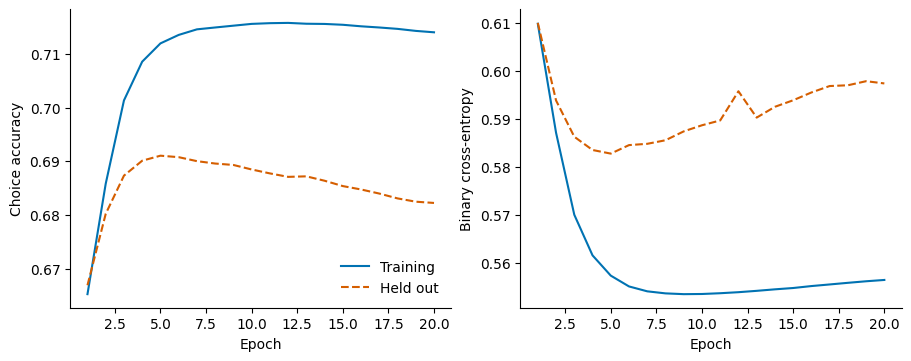

,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,401,47574,90,2970347,2650103,320244,0.597383,0.682242,0.682242,8,764.08123


,uuid,z1,z2
0,000057c7-295c-4a61-8f62-76aff62bf079,0.677150,0.408329
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.159913,0.444107
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.558965,0.849931
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.342505,0.456696
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.237411,0.554614
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.494192,0.583515
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.406605,0.153470
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.705839,0.835053
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.236867,0.490230


,id,z1,z2
0,1,6.751020e-02,6.396167e-01
1,2,1.399427e-08,9.451686e-07
2,3,2.946342e-01,5.741237e-01
3,4,1.259170e-01,7.952459e-01
4,5,3.071077e-01,1.589249e-01
...,...,...,...
85,86,2.347043e-01,7.794999e-01
86,87,2.245963e-01,5.431587e-01
87,88,4.037817e-01,9.340746e-01
88,89,4.944639e-01,3.735251e-01


Model: "dynamap_intermediate"


_________________________________________________________________


...

_________________________________________________________________


{'dimension': 2,
 'embedding_seed': 401,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 90,
 'n_users': 47574,
 'seed': 401,
 'variant': 'intermediate'}

Loading Chile_dim2_seed501: 47,574 participants, 2,650,103 training choices.


,tensor,shape,parameters
0,proposal_coordinates:0,"(90, 2)",180
1,participant_coordinates:0,"(47574, 2)",95148
2,symmetric_positive_choice/kernel:0,"(2, 8)",16
3,symmetric_positive_choice/bias:0,"(8,)",8
4,symmetric_positive_choice/kernel:0,"(8, 8)",64
5,symmetric_positive_choice/bias:0,"(8,)",8
6,symmetric_positive_choice/kernel:0,"(8, 1)",8
7,symmetric_positive_choice/bias:0,"(1,)",1


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.608409,0.666241,0.605652,0.669486
1,2,0.581590,0.690236,0.587605,0.685477
2,3,0.563303,0.705600,0.581294,0.691657
3,4,0.556522,0.711021,0.579702,0.693118
4,5,0.553704,0.713730,0.579626,0.693100
5,6,0.552106,0.715047,0.580239,0.693209
6,7,0.551277,0.716039,0.581757,0.692691
7,8,0.550942,0.716627,0.582615,0.691985
8,9,0.550905,0.717034,0.584863,0.691866
9,10,0.550972,0.717162,0.583804,0.690951


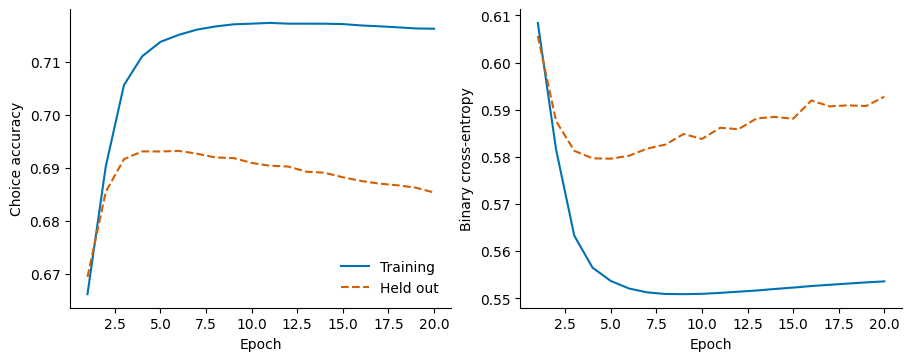

,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,501,47574,90,2970347,2650103,320244,0.592766,0.685374,0.685374,8,801.699411


,uuid,z1,z2
0,000057c7-295c-4a61-8f62-76aff62bf079,0.438286,0.783826
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.248257,0.661631
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.304207,0.198763
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.358137,0.498592
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.342330,0.542024
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.228073,0.407487
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.642888,0.779099
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.568279,0.065376
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.306975,0.591589


,id,z1,z2
0,1,0.033393,0.583851
1,2,1.000000,0.798232
2,3,0.313575,0.510413
3,4,0.011316,0.406060
4,5,0.601625,0.897224
...,...,...,...
85,86,0.109844,0.344967
86,87,0.304930,0.574214
87,88,0.151663,0.097617
88,89,0.654287,0.560162


Model: "dynamap_intermediate"


_________________________________________________________________


...

Total params: 95433 (372.79 KB)


Trainable params: 95433 (372.79 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


{'dimension': 2,
 'embedding_seed': 501,
 'hidden_sizes': [8, 8],
 'minimum_scale': 1e-06,
 'n_options': 90,
 'n_users': 47574,
 'seed': 501,
 'variant': 'intermediate'}

In [3]:
# Refuse to combine the paper's main fit with a different head or sample.
main_specification = json.loads(
    (OUTPUT / "models/Chile_dim2_seed101/model_specification.json").read_text()
)
expected_main = dict(
    n_options=len(options),
    n_users=len(users),
    dimension=2,
    seed=101,
    embedding_seed=101,
    variant=VARIANT,
)
if VARIANT == "intermediate":
    expected_main.update(hidden_sizes=list(HIDDEN_SIZES), minimum_scale=MINIMUM_SCALE)
assert (
    main_specification == expected_main
), "Regenerate the matching main fit in notebook 02 first."

additional_metrics = []
for dimension, seed in FIT_SPECIFICATIONS:
    run_name = f"Chile_dim{dimension}_seed{seed}"
    run = OUTPUT / "models" / run_name
    run.mkdir(parents=True, exist_ok=True)
    print(
        f"{'Training' if REFIT else 'Loading'} {run_name}: {len(users):,} participants, {len(y_train):,} training choices."
    )
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = (
        train_dataset.shuffle(len(y_train)).batch(BATCH_SIZE, drop_remainder=False).repeat()
    )
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
    test_dataset = test_dataset.batch(BATCH_SIZE, drop_remainder=False).repeat()

    with tf.device(DEVICE):
        model = build_choice_model(len(options), len(users), dimension, seed, **MODEL_SETTINGS)
        model.compile(
            optimizer=tf.keras.optimizers.Adamax(learning_rate=LEARNING_RATE),
            loss=tf.keras.losses.BinaryCrossentropy(),
            metrics=["accuracy"],
            steps_per_execution=STEPS_PER_EXECUTION,
        )
    # Check fit identity before overwriting any model-derived tables.
    model_specification = json.loads(model.choice_configuration_json)
    if not REFIT:
        saved_specification = json.loads((run / "model_specification.json").read_text())
        assert (
            model_specification == saved_specification
        ), "Requested model differs from the supplied fit. Use REFIT=True."
        assert pd.read_csv(run / "coordsU.csv")["uuid"].tolist() == users.tolist()
        assert pd.read_csv(run / "coordsP.csv")["id"].tolist() == options.tolist()
        model.load_weights(str(run / "model.weights.h5"))

    parameter_table = pd.DataFrame(
        [
            {
                "tensor": variable.name,
                "shape": str(tuple(variable.shape)),
                "parameters": int(np.prod(variable.shape)),
            }
            for variable in model.trainable_variables
        ]
    )
    display(parameter_table)
    parameter_table.to_csv(run / "trainable_parameters.csv", index=False)
    parameter_table.to_latex(run / "trainable_parameters.tex", index=False)

    if REFIT:
        started = time.perf_counter()
        with tf.device(DEVICE):
            history = model.fit(
                train_dataset,
                epochs=EPOCHS,
                steps_per_epoch=int(np.ceil(len(y_train) / BATCH_SIZE)),
                validation_data=test_dataset,
                validation_steps=int(np.ceil(len(y_test) / BATCH_SIZE)),
                verbose=2,
            )
        elapsed_seconds = time.perf_counter() - started
        history_table = pd.DataFrame(history.history)
        history_table.insert(0, "epoch", np.arange(1, len(history_table) + 1))
    else:
        history_table = pd.read_csv(run / "history.csv")
        elapsed_seconds = float(pd.read_csv(run / "metrics.csv").iloc[0]["seconds"])
    if REFIT:
        assert len(history_table) == EPOCHS
    assert np.isfinite(history_table.select_dtypes("number")).all().all()
    display(history_table)
    history_table.to_csv(run / "history.csv", index=False)
    history_table.to_latex(run / "history.tex", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")
    for axis, metric, label in zip(
        axes, ["accuracy", "loss"], ["Choice accuracy", "Binary cross-entropy"]
    ):
        axis.plot(
            history_table["epoch"], history_table[metric], color="#0072B2", label="Training"
        )
        axis.plot(
            history_table["epoch"],
            history_table[f"val_{metric}"],
            color="#D55E00",
            linestyle="--",
            label="Held out",
        )
        axis.set(xlabel="Epoch", ylabel=label)
        axis.spines[["top", "right"]].set_visible(False)
    axes[0].legend(frameon=False)
    display(fig)
    fig.savefig(OUTPUT / "figures" / f"{run_name}_training.pdf", bbox_inches="tight")
    plt.close(fig)

    with tf.device(DEVICE):
        evaluation = model.evaluate(
            X_test, y_test, batch_size=BATCH_SIZE, verbose=0, return_dict=True
        )
    metrics = pd.DataFrame(
        [
            {
                "country": "Chile",
                "dimension": dimension,
                "seed": seed,
                "participants": len(users),
                "proposals": len(options),
                "records": len(ordered),
                "training_records": len(y_train),
                "test_records": len(y_test),
                "test_loss_all_records": evaluation["loss"],
                "test_accuracy_all_records": evaluation["accuracy"],
                "last_epoch_test_accuracy": history_table.iloc[-1]["val_accuracy"],
                "singleton_participants_assigned_to_train": singleton_count,
                "seconds": elapsed_seconds,
            }
        ]
    )
    display(metrics)
    metrics.to_csv(run / "metrics.csv", index=False)
    metrics.to_latex(run / "metrics.tex", index=False)
    additional_metrics.append(metrics)

    coordinate_columns = [f"z{i + 1}" for i in range(dimension)]
    participant_coordinates = pd.DataFrame(
        model.layers[0].returnUsersEmbedding().numpy(), columns=coordinate_columns
    )
    participant_coordinates.insert(0, "uuid", users)
    proposal_coordinates = pd.DataFrame(
        model.layers[0].returnOptionsEmbedding().numpy(), columns=coordinate_columns
    )
    proposal_coordinates.insert(0, "id", options)
    assert not set(participant_coordinates["uuid"]) & excluded_ids
    for coordinates, filename in [
        (participant_coordinates, "coordsU.csv"),
        (proposal_coordinates, "coordsP.csv"),
    ]:
        assert np.isfinite(coordinates[coordinate_columns]).all().all()
        display(coordinates)
        coordinates.to_csv(run / filename, index=False)
    model.summary()
    display(model_specification)
    if REFIT:
        model.save_weights(str(run / "model.weights.h5"))
        (run / "model_specification.json").write_text(
            json.dumps(model_specification, indent=2) + "\n"
        )
        properties = {
            "country": "Chile",
            "dimension": dimension,
            "seed": seed,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "steps_per_execution": STEPS_PER_EXECUTION,
            "device": DEVICE,
            "architecture": VARIANT,
            "model_configuration": MODEL_SETTINGS,
            "checkpoint_selection": "fixed_final_epoch",
            "tensorflow_version": tf.__version__,
            "participants": len(users),
            "proposals": len(options),
            "included_missing_age": True,
            "singleton_choice_assigned_to_train": True,
            "drop_remainder": False,
        }
        display(properties)
        (run / "properties.json").write_text(json.dumps(properties, indent=2) + "\n")


## Compare dimensions and initializations

The supplied main `(2, 101)` fit is combined with the eight fits above. Its head must match the selected architecture. When experimenting with another head, first generate the corresponding main fit in notebook 02 and use the same output directory here. Sample and split sizes must match across all nine fits.

The dimension comparison holds seed 101 fixed. The initialization comparison holds two dimensions fixed. All final metrics below come from the same filtered sample.


,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
1,Chile,1,101,47574,90,2970347,2650103,320244,0.608686,0.650666,0.650666,8,654.401812
0,Chile,2,101,47574,90,2970347,2650103,320244,0.594979,0.680987,0.680987,8,633.565454
5,Chile,2,201,47574,90,2970347,2650103,320244,0.593649,0.684375,0.684375,8,818.428899
6,Chile,2,301,47574,90,2970347,2650103,320244,0.589048,0.686483,0.686483,8,714.493242
7,Chile,2,401,47574,90,2970347,2650103,320244,0.597383,0.682242,0.682242,8,764.081230
8,Chile,2,501,47574,90,2970347,2650103,320244,0.592766,0.685374,0.685374,8,801.699411
2,Chile,3,101,47574,90,2970347,2650103,320244,0.566223,0.703317,0.703317,8,2149.870067
3,Chile,4,101,47574,90,2970347,2650103,320244,0.560734,0.708376,0.708376,8,1159.752744
4,Chile,10,101,47574,90,2970347,2650103,320244,0.556558,0.717668,0.717668,8,2683.109397


,dimension,test_loss_all_records,test_accuracy_all_records
0,1,0.608686,0.650666
1,2,0.594979,0.680987
2,3,0.566223,0.703317
3,4,0.560734,0.708376
4,10,0.556558,0.717668


,seed,test_loss_all_records,test_accuracy_all_records
0,101,0.594979,0.680987
1,201,0.593649,0.684375
2,301,0.589048,0.686483
3,401,0.597383,0.682242
4,501,0.592766,0.685374


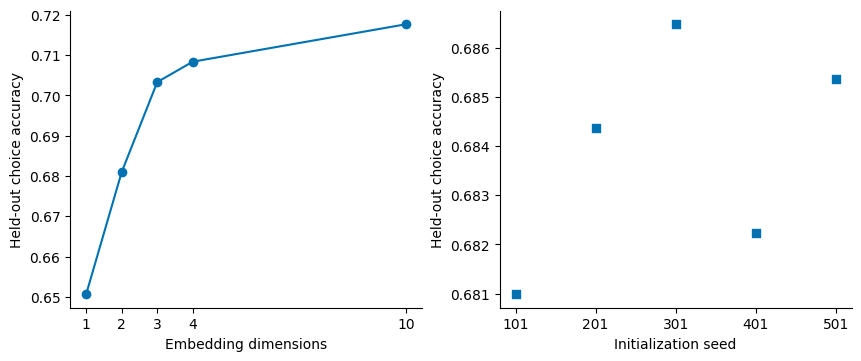

In [4]:
main_metrics = pd.read_csv(OUTPUT / "models" / "Chile_dim2_seed101" / "metrics.csv")
all_metrics = pd.concat([main_metrics, *additional_metrics], ignore_index=True).sort_values(
    ["dimension", "seed"]
)
assert len(all_metrics) == 1 + len(FIT_SPECIFICATIONS)
assert not all_metrics.duplicated(["dimension", "seed"]).any()
for column in ["participants", "proposals", "records", "training_records", "test_records"]:
    assert all_metrics[column].nunique() == 1, f"The fits disagree on {column}."
display(all_metrics)
all_metrics.to_csv(OUTPUT / "diagnostics" / "Chile_all_fit_metrics.csv", index=False)
all_metrics.to_latex(OUTPUT / "diagnostics" / "Chile_all_fit_metrics.tex", index=False)

dimension_table = all_metrics.loc[
    all_metrics["seed"].eq(101),
    ["dimension", "test_loss_all_records", "test_accuracy_all_records"],
].reset_index(drop=True)
display(dimension_table)
dimension_table.to_csv(OUTPUT / "diagnostics" / "Chile_dimensionality.csv", index=False)
dimension_table.to_latex(
    OUTPUT / "diagnostics" / "Chile_dimensionality.tex", index=False, float_format="%.4f"
)
initialization_table = (
    all_metrics.loc[
        all_metrics["dimension"].eq(2),
        ["seed", "test_loss_all_records", "test_accuracy_all_records"],
    ]
    .sort_values("seed")
    .reset_index(drop=True)
)
display(initialization_table)
initialization_table.to_csv(
    OUTPUT / "diagnostics" / "Chile_initialization_metrics.csv", index=False
)
initialization_table.to_latex(
    OUTPUT / "diagnostics" / "Chile_initialization_metrics.tex",
    index=False,
    float_format="%.4f",
)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.5), layout="constrained")
axes[0].plot(
    dimension_table["dimension"],
    dimension_table["test_accuracy_all_records"],
    marker="o",
    color="#0072B2",
)
axes[0].set(
    xlabel="Embedding dimensions",
    ylabel="Held-out choice accuracy",
    xticks=dimension_table["dimension"].tolist(),
)
axes[1].scatter(
    initialization_table["seed"].astype(str),
    initialization_table["test_accuracy_all_records"],
    marker="s",
    color="#0072B2",
)
axes[1].set(xlabel="Initialization seed", ylabel="Held-out choice accuracy")
for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
display(fig)
fig.savefig(
    OUTPUT / "figures" / "Chile_dimensionality_and_initialization.pdf", bbox_inches="tight"
)
plt.close(fig)
